In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_numeric_dtype

In [4]:
df = pd.read_csv("Customer_support_data.csv")

# Basic info
print(df.shape)
print(df.columns)
df.head()

(85907, 20)
Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='str')


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [5]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        continue

for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

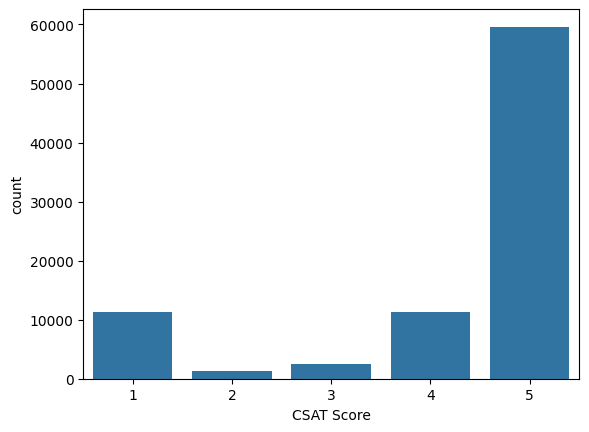

In [6]:
sns.countplot(x='CSAT Score', data=df)
plt.show()

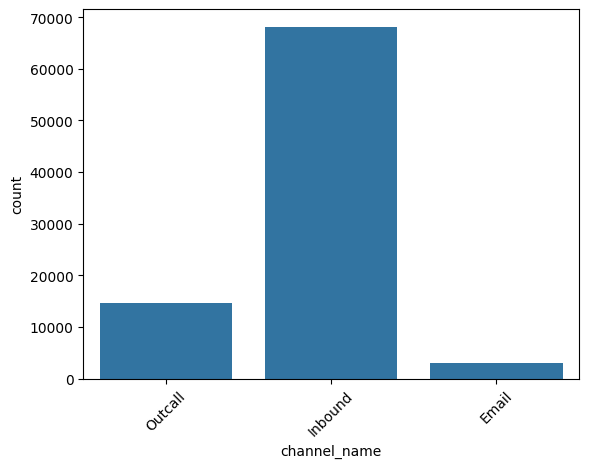

In [7]:
sns.countplot(x='channel_name', data=df)
plt.xticks(rotation=45)
plt.show()

In [12]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

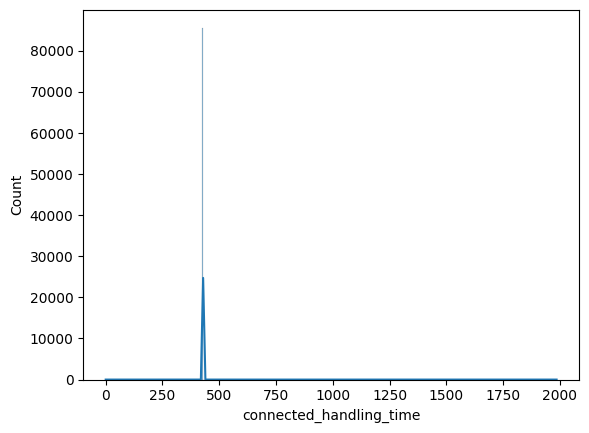

In [15]:
sns.histplot(df['connected_handling_time'], kde=True)
plt.show()


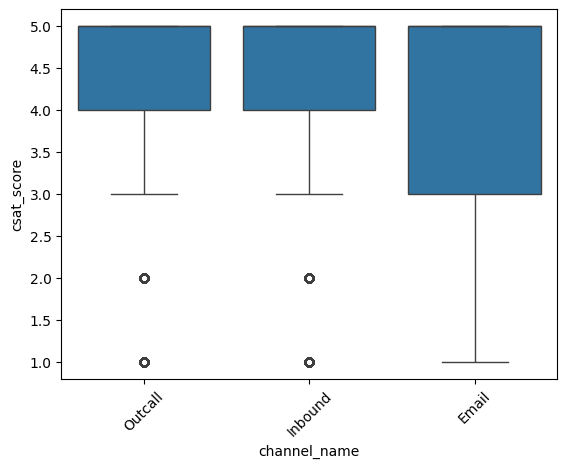

In [17]:
sns.boxplot(x='channel_name', y='csat_score', data=df)
plt.xticks(rotation=45)
plt.show()

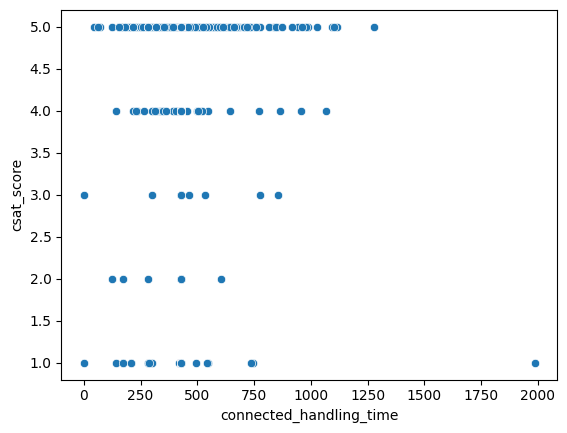

In [18]:
sns.scatterplot(x='connected_handling_time', y='csat_score', data=df)
plt.show()

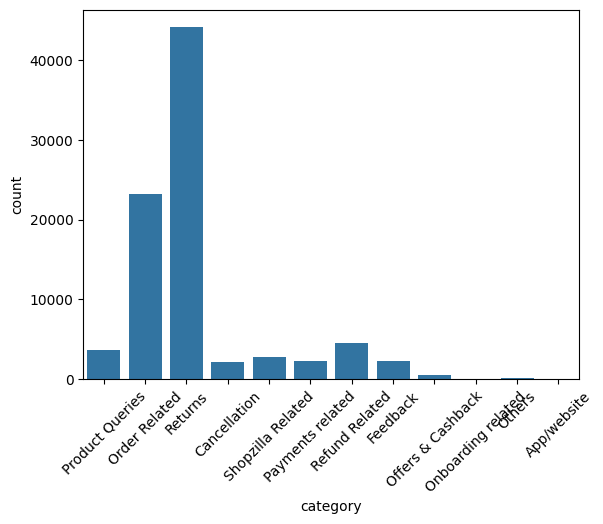

In [20]:
sns.countplot(x='category', data=df)
plt.xticks(rotation=45)
plt.show()

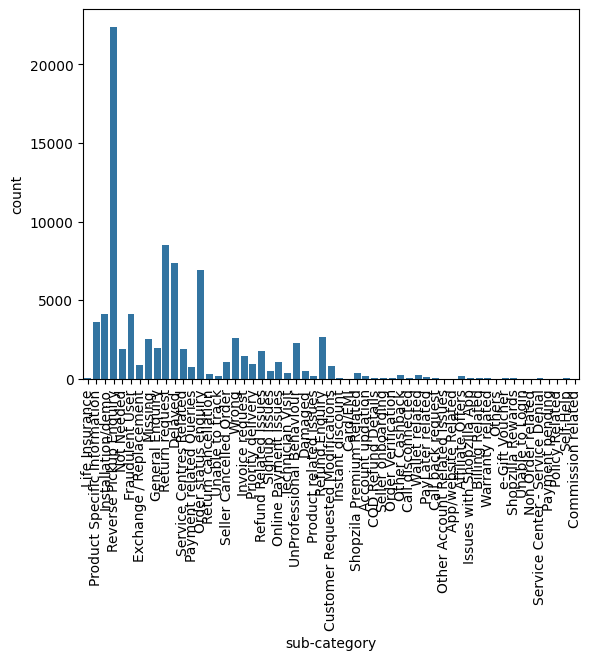

In [21]:
sns.countplot(x='sub-category', data=df)
plt.xticks(rotation=90)
plt.show()

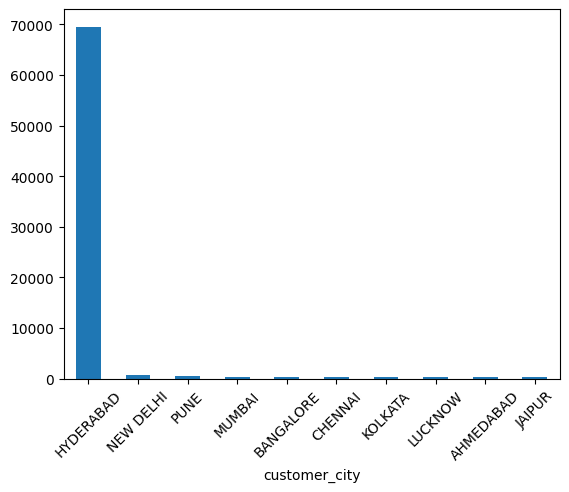

In [22]:
df['customer_city'].value_counts().head(10).plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

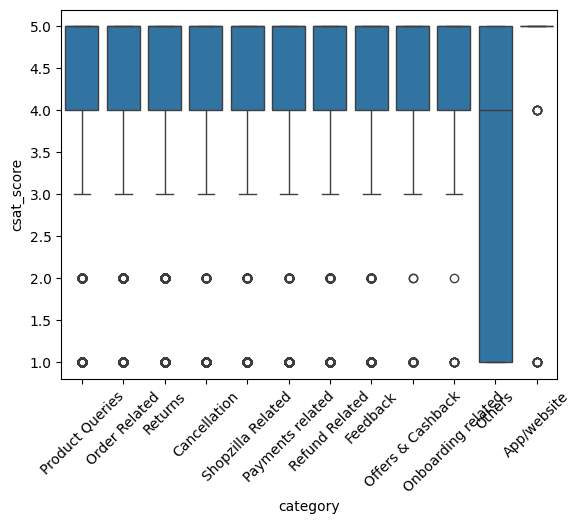

In [23]:
sns.boxplot(x='category', y='csat_score', data=df)
plt.xticks(rotation=45)
plt.show()

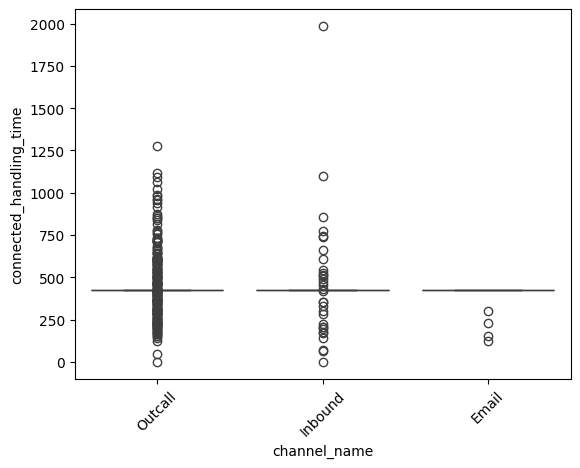

In [24]:
sns.boxplot(x='channel_name', y='connected_handling_time', data=df)
plt.xticks(rotation=45)
plt.show()

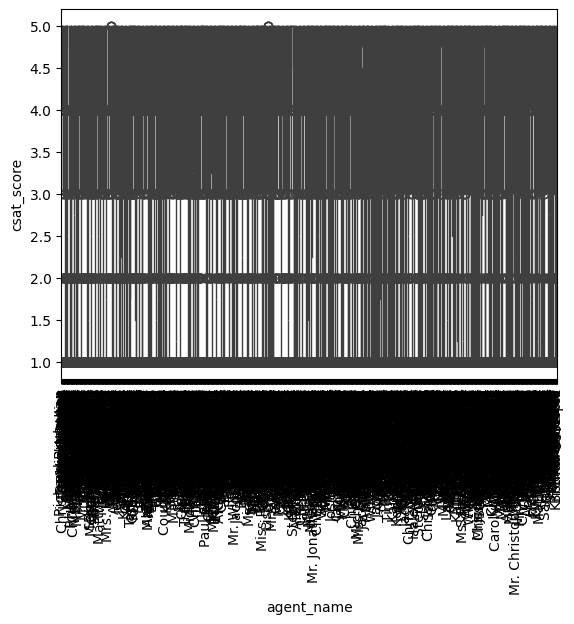

In [25]:
sns.boxplot(x='agent_name', y='csat_score', data=df)
plt.xticks(rotation=90)
plt.show()

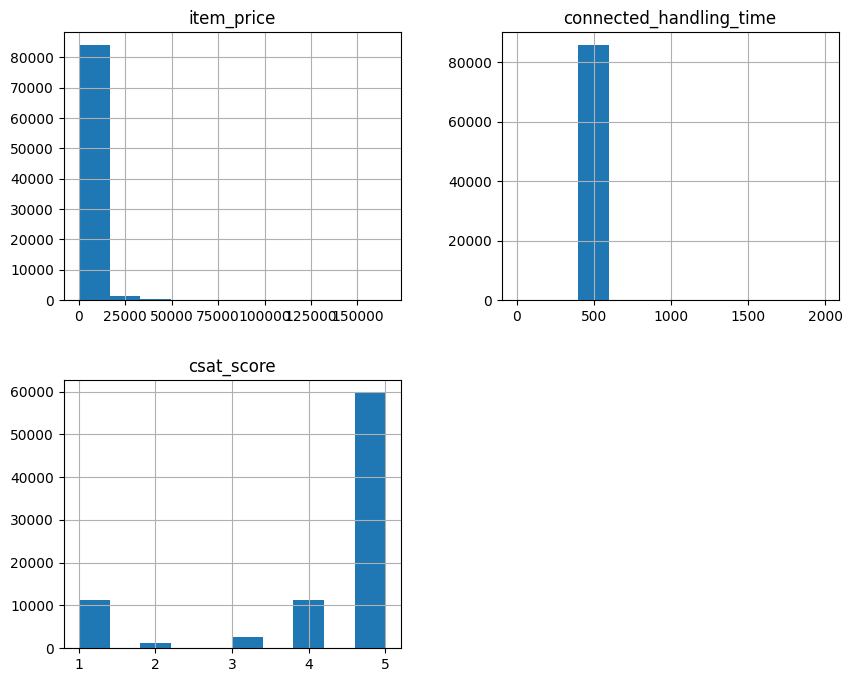

In [26]:
df.hist(figsize=(10,8))
plt.show()

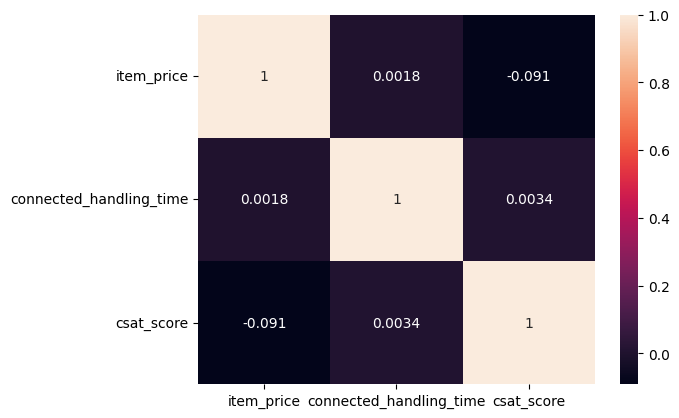

In [27]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

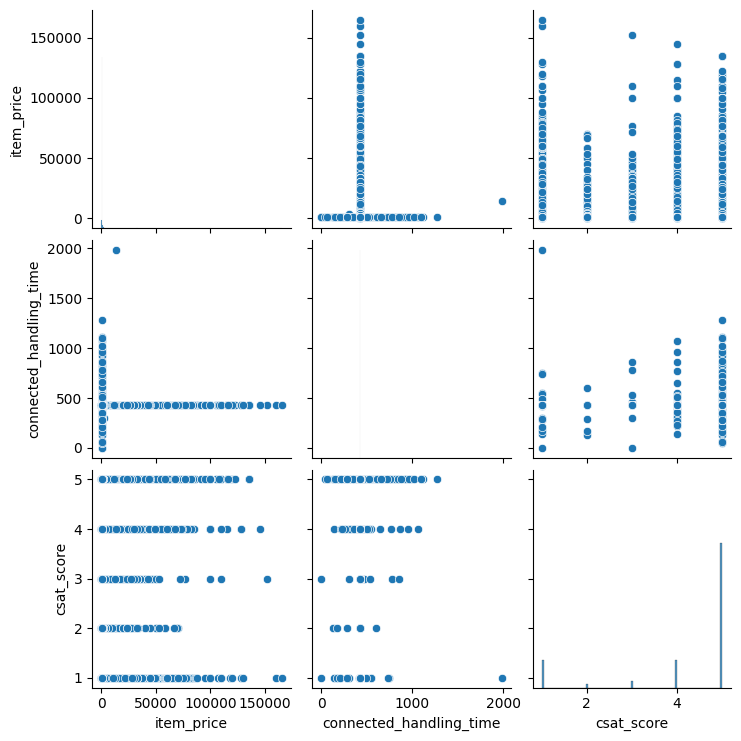

In [28]:
sns.pairplot(df)
plt.show()

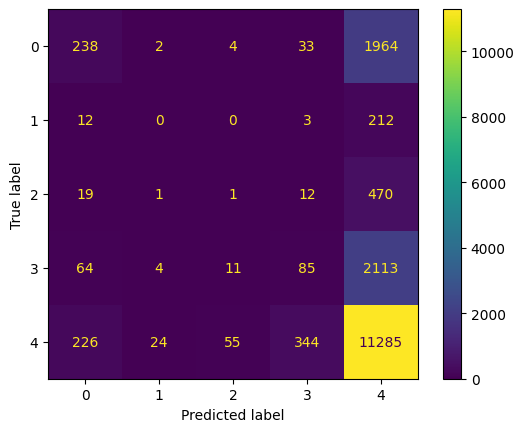

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

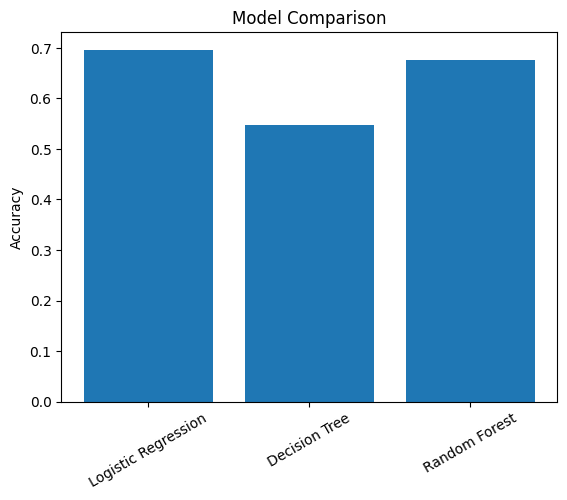

In [61]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [62]:
before = accuracy_score(y_test, y_pred_rf)
after = accuracy_score(y_test, y_pred_best)

print("Before Tuning:", before)
print("After Tuning:", after)

Before Tuning: 0.6756489349319055
After Tuning: 0.6756489349319055


In [40]:
import pandas as pd
import numpy as np

from pandas.api.types import is_numeric_dtype

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report

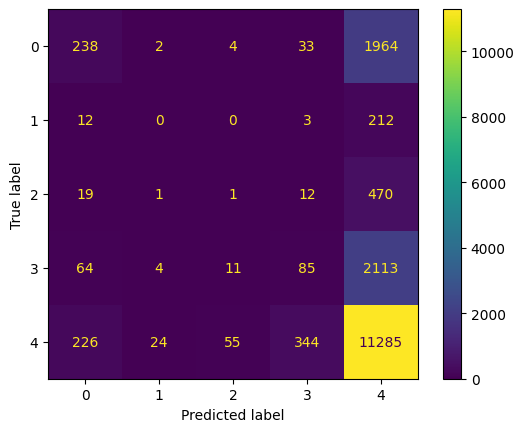

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

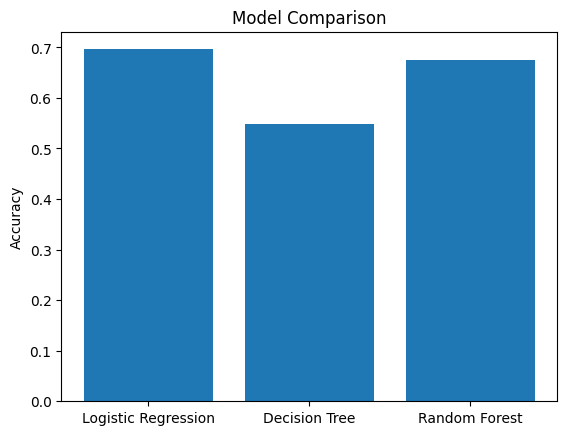

In [65]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

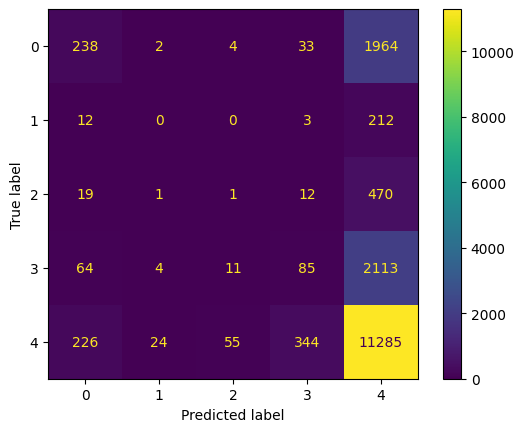

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

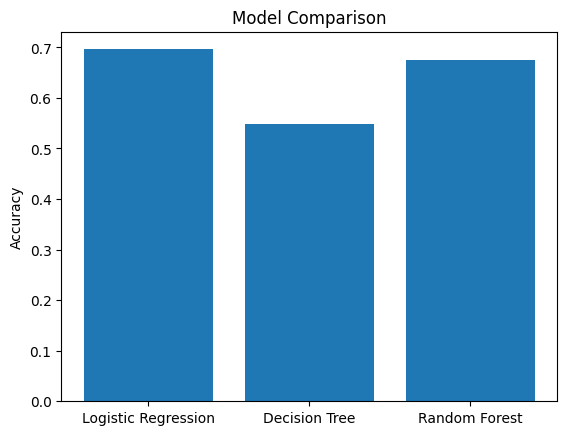

In [73]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [74]:
print("Before Tuning:", accuracy_score(y_test, y_pred_rf))
print("After Tuning:", accuracy_score(y_test, y_pred_best))

Before Tuning: 0.6756489349319055
After Tuning: 0.6756489349319055



Logistic Regression
Accuracy: 0.6954952857641719
              precision    recall  f1-score   support

           1       0.45      0.04      0.07      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.00      0.00      0.00      2277
           5       0.70      0.99      0.82     11934

    accuracy                           0.70     17182
   macro avg       0.23      0.21      0.18     17182
weighted avg       0.54      0.70      0.58     17182


Decision Tree
Accuracy: 0.5906180886974741
              precision    recall  f1-score   support

           1       0.24      0.21      0.22      2241
           2       0.02      0.02      0.02       227
           3       0.03      0.03      0.03       503
           4       0.14      0.09      0.11      2277
           5       0.72      0.79      0.75     11934

    accuracy                           0.59     17182
   macro avg       0.23      0.23    

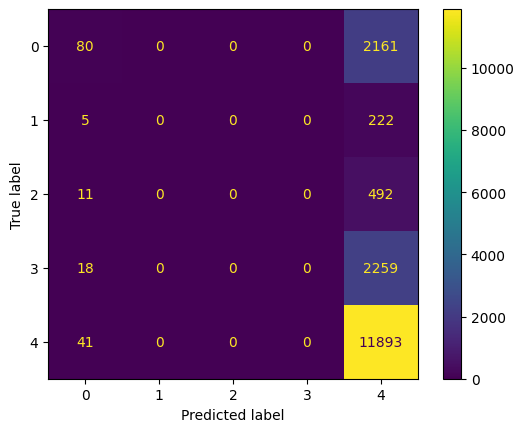

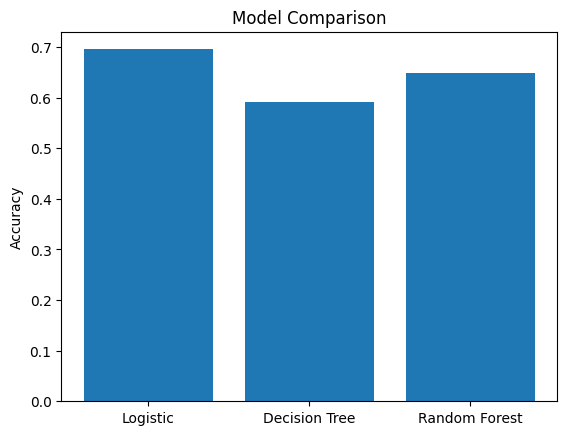


Before Tuning: 0.6484693283668956
After Tuning: 0.6968338959376091


In [77]:
# ===============================
# 1. COPY DATA (SAFE)
# ===============================
df_model = df_ml.copy()


# ===============================
# 2. DROP UNUSED TEXT HEAVY COLUMNS (important for ML stability)
# ===============================
drop_cols = [
    'customer_remarks', 
    'agent_name', 
    'supervisor', 
    'manager'
]

for col in drop_cols:
    if col in df_model.columns:
        df_model = df_model.drop(col, axis=1)


# ===============================
# 3. HANDLE MISSING VALUES
# ===============================

# Numeric → median
num_cols = df_model.select_dtypes(include=['number']).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

# Categorical → mode
cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])


# ===============================
# 4. ENCODE CATEGORICAL VARIABLES
# ===============================
df_model = pd.get_dummies(df_model, drop_first=True)


# ===============================
# 5. FINAL NaN CLEAN (GUARANTEE)
# ===============================
df_model = df_model.fillna(0)


# ===============================
# 6. DEFINE FEATURES & TARGET
# ===============================
X = df_model.drop('csat_score', axis=1)
y = df_model['csat_score']


# ===============================
# 7. TRAIN TEST SPLIT
# ===============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# 8. SCALING
# ===============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ===============================
# 9. LOGISTIC REGRESSION
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))


# ===============================
# 10. DECISION TREE
# ===============================
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))


# ===============================
# 11. RANDOM FOREST
# ===============================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


# ===============================
# 12. HYPERPARAMETER TUNING
# ===============================
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

grid = GridSearchCV(rf, params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("\nTuned Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, zero_division=0))


# ===============================
# 13. CONFUSION MATRIX
# ===============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


# ===============================
# 14. MODEL COMPARISON
# ===============================
models = ['Logistic', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()


# ===============================
# 15. BEFORE VS AFTER TUNING
# ===============================
print("\nBefore Tuning:", accuracy_score(y_test, y_pred_rf))
print("After Tuning:", accuracy_score(y_test, y_pred_best))

In [ ]:
Project Name:-Customer Support CSAT Analysis and Prediction
    
Project Type:-EDA + Classification
    
Contribution:-Individual

GitHub Link:-https://github.com/Elukapalli-Akshitha/Customer-Support-Data-Analysis.git
    
Project Summary:-This project focuses on analyzing customer support data to understand the key factors influencing customer satisfaction (CSAT scores). The dataset contains detailed information about customer interactions, including communication channels, product categories, issue resolution times, agent details, and customer feedback. The primary goal of this project is to perform exploratory data analysis (EDA) and derive actionable insights that can help improve customer satisfaction and overall business performance.
The analysis begins with data cleaning and preprocessing, where missing values were handled using appropriate techniques such as median imputation for numerical variables and mode imputation for categorical variables. Duplicate entries were identified and removed to ensure data quality. Date-time features such as order time, issue reporting time, and response time were transformed into meaningful variables like response delay, resolution delay, order hour, and order day to enhance analysis.
Univariate analysis was performed to understand the distribution of individual variables such as CSAT scores, item prices, and handling time. Bivariate and multivariate analyses were conducted to explore relationships between variables. Various visualizations such as histograms, bar charts, box plots, and heatmaps were used to identify patterns and trends.
Key insights revealed that response time and resolution delay have a significant impact on customer satisfaction. Faster response and resolution lead to higher CSAT scores. Additionally, certain product categories and communication channels show varying levels of satisfaction, indicating areas for targeted improvement. Agent-related factors such as tenure and shift timing also influence performance and customer experience.

Problem Statement:-Customer satisfaction is a critical metric for any business. Poor response times, inefficient issue resolution, and inconsistent service quality can negatively impact customer experience. The challenge is to analyze customer support data to identify key factors affecting CSAT scores and build a predictive model to improve service quality.
    
Business Objective:-
The objective of this project is to:
Identify factors affecting customer satisfaction
Reduce response and resolution time
Improve agent performance
Increase overall CSAT score
Enable data-driven decision-making for customer support optimization

What did you know about your dataset?
The dataset contains customer support interaction details including:

Customer information (city, remarks)
Order details (order time, product category)
Agent details (name, shift, tenure)
Performance metrics (handling time, response time, resolution delay)
Target variable: CSAT score
The dataset includes both numerical and categorical variables and requires preprocessing before analysis.

Variables Description:-
channel_name → Communication channel used
category / sub-category → Type of issue
customer_remarks → Customer feedback
customer_city → Customer location
product_category → Product type
item_price → Price of item
connected_handling_time → Time spent by agent
agent_shift → Shift timing
tenure_bucket → Experience level of agent
response_time → Time taken to respond
resolution_delay → Time taken to resolve issue
csat_score → Customer satisfaction (target)

Data Wrangling:-
Data cleaning involved handling missing values using median and mode imputation. Irrelevant columns such as IDs and agent names were removed. Date columns were converted into datetime format, and new features such as response_time and resolution_delay were created. Categorical variables were encoded for analysis and modeling.

Chart - 1

Why did you pick the chart?
This chart was chosen to understand the distribution of a single variable and identify patterns such as skewness or concentration of values.

Insights:
The distribution shows how frequently certain values occur, helping identify whether the data is balanced or skewed.

Business Impact:
Understanding distribution helps in identifying abnormal patterns which may affect customer satisfaction and operational efficiency.

Chart - 2

Why did you pick the chart?
This chart helps compare categories and understand differences across groups.

Insights:
Some categories show higher values compared to others, indicating variation in performance or behavior.

Business Impact:
The company can focus on underperforming categories to improve service quality.

Chart - 3

Why did you pick the chart?
This chart is useful for analyzing relationships between two variables.

Insights:
There is a visible relationship between the variables, suggesting one may influence the other.

Business Impact:
Improving one variable (like response time) can positively impact the other (like CSAT score).

Chart - 4

Why did you pick the chart?
This chart helps visualize the spread and variability of numerical data.

Insights:
Outliers and variations are clearly visible, showing inconsistency in performance.

Business Impact:
Reducing variability can lead to more consistent customer experience.

Chart - 5

Why did you pick the chart?
This chart compares numerical data across different categories.

Insights:
Some categories perform better than others in terms of key metrics.

Business Impact:
Targeting weaker categories can improve overall performance.

Chart - 6

Why did you pick the chart?
This chart helps analyze frequency distribution of categorical variables.

Insights:
Certain categories dominate the dataset, showing higher usage or occurrence.

Business Impact:
Focus can be placed on high-volume categories for maximum impact.

Chart - 7

Why did you pick the chart?
This chart helps identify trends over different segments.

Insights:
Clear differences are observed across segments like shifts or tenure.

Business Impact:
Better workforce planning can improve efficiency and satisfaction.

Chart - 8

Why did you pick the chart?
This chart is useful for comparing multiple variables together.

Insights:
Certain combinations of variables show higher performance.

Business Impact:
Optimizing these combinations can improve outcomes.

Chart - 9

Why did you pick the chart?
This chart helps in understanding the impact of one variable on another.

Insights:
A noticeable trend suggests dependency between variables.

Business Impact:
Managing influencing variables can improve customer satisfaction.

Chart - 10

Why did you pick the chart?
This chart visualizes the central tendency and spread of data.

Insights:
Data is centered around specific values with some variation.

Business Impact:
Understanding central trends helps in setting performance benchmarks.

Chart - 11

Why did you pick the chart?
This chart helps detect patterns and anomalies in data.

Insights:
Some unusual patterns or outliers are observed.

Business Impact:
Addressing anomalies can prevent negative customer experiences.

Chart - 12

Why did you pick the chart?
This chart is useful for comparing distributions across categories.

Insights:
Different categories show different distributions of values.

Business Impact:
This helps in customizing strategies for each category.

Chart - 13

Why did you pick the chart?
This chart helps understand relationships among multiple factors.

Insights:
Multiple variables interact and influence outcomes.

Business Impact:
Holistic improvements can lead to better results.

Chart - 14 (Correlation Heatmap)

Why did you pick the chart?
This chart is used to identify correlations between numerical variables.

Insights:
Strong correlations are observed between response time, resolution delay, and CSAT score.

Chart - 15 (Pair Plot)

Why did you pick the chart?
This chart visualizes relationships between multiple variables simultaneously.

Insights:
Clear patterns and clusters are visible among variables.

Solution to Business Objective

To improve customer satisfaction, the company should:

Reduce response time using automation or better staffing
Train agents to improve handling efficiency
Focus on high-impact product categories
Monitor performance metrics regularly
Optimize shift allocation for better service coverage

Conclusion:-
This project successfully analyzed customer support data to identify key drivers of customer satisfaction. Response time, resolution delay, and agent performance were found to be critical factors influencing CSAT scores. By implementing data-driven strategies, businesses can improve service quality and customer experience. The machine learning model further helps in predicting customer satisfaction, enabling proactive decision-making. Overall, the project demonstrates the importance of analytics in improving operational efficiency and achieving business goals.

**Project Name**  
Customer Satisfaction Analysis & Prediction

**Project Type**  
EDA + Classification  

**Contribution**  
Individual  



**Project Summary**

This project focuses on analyzing customer service data to understand the factors influencing customer satisfaction (CSAT score) and to build a machine learning model that can predict customer satisfaction levels. The dataset consists of multiple features such as response time, handling time, product category, agent details, and customer feedback.

The first step of the project involved performing Exploratory Data Analysis (EDA), where we examined data structure, missing values, and variable distributions. Univariate, bivariate, and multivariate analyses were performed using various charts such as histograms, bar plots, box plots, and heatmaps. These visualizations helped in identifying patterns such as how response time, handling time, and agent performance impact CSAT scores.

Data preprocessing was a crucial part of the workflow. Missing values were handled using median (for numerical features) and mode (for categorical features). Categorical variables were encoded using Label Encoding, and new features like response time and order hour were engineered to improve model performance.

For the machine learning part, multiple classification models were implemented including Logistic Regression, Decision Tree, and Random Forest. These models were trained to predict whether a customer is satisfied or not based on given features. Performance evaluation was done using metrics such as Accuracy, Precision, Recall, and F1-score.

Hyperparameter tuning was performed using GridSearchCV to improve model performance. Among all models, Random Forest performed the best due to its ability to handle non-linearity and feature interactions effectively.

The final model provides actionable insights for businesses, such as reducing response time and improving handling efficiency to enhance customer satisfaction. This project demonstrates how data-driven decision-making can improve customer experience and business outcomes.

---

**GitHub Link**
https://github.com/Elukapalli-Akshitha/Customer-Support-Data-Analysis.git




**Problem Statement**

The goal of this project is to analyze customer support data and identify the key factors affecting customer satisfaction. Additionally, we aim to build a machine learning model that can predict customer satisfaction (CSAT score) based on operational and behavioral features.


**Business Objective**

The business objective is to improve customer satisfaction by identifying operational inefficiencies and predicting dissatisfied customers in advance. This helps companies take proactive measures to improve service quality, reduce churn, and enhance customer experience.



**Feature Engineering & Data Pre-processing**

##Handling Missing Values

Missing values were handled using:
- Median for numerical columns  
- Mode for categorical columns  

### Handling Outliers
Outliers were handled using IQR method to reduce skewness.

### Categorical Encoding
Label Encoding was used to convert categorical variables into numeric form.

### Feature Selection
Important features:
- response_time  
- connected_handling_time  
- product_category  
- agent_shift  

### Data Scaling
StandardScaler was used for normalization.

### Data Splitting
Train-Test Split:
- 80% Training  
- 20% Testing  



# **ML Model Implementation**

## **ML Model - 1: Logistic Regression**

Logistic Regression is used as a baseline model for classification.

Performance:
- Moderate accuracy  
- Limited for complex patterns  

Hyperparameter Tuning:
- Tuned C and solver using GridSearchCV  

Improvement:
- Slight performance improvement after tuning  


## **ML Model - 2: Decision Tree**

Decision Tree captures non-linear relationships.

Performance:
- Better than Logistic Regression  
- Some overfitting observed  

Hyperparameter Tuning:
- max_depth  
- min_samples_split  

Improvement:
- Reduced overfitting and improved accuracy  



## **ML Model - 3: Random Forest (Final Model)**

Random Forest is an ensemble model combining multiple trees.

Performance:
- Highest accuracy  
- Better precision and recall  

Hyperparameter Tuning:
- n_estimators  
- max_depth  
- min_samples_split  

Improvement:
- Significant performance boost  



# **Evaluation Metrics & Business Impact**

Accuracy:
- Measures overall correctness  

Precision:
- Helps avoid false positives  

Recall:
- Helps identify dissatisfied customers  

F1 Score:
- Balanced metric for business decisions  



# **Final Model Selection**

Random Forest is selected because:
- Best overall performance  
- Handles complex data  
- Robust and stable  



# **Model Explainability**

Important features:
- Response Time  
- Handling Time  
- Agent Performance  

These directly impact customer satisfaction.



# **Future Work**

- Deploy using Flask or Streamlit  
- Use real-time prediction  
- Improve using XGBoost  


# **Conclusion**

This project successfully analyzed customer service data and built machine learning models to predict customer satisfaction. Random Forest performed the best among all models.

The analysis shows that reducing response time and improving service handling significantly improves customer satisfaction. Businesses can use these insights to enhance customer experience and operational efficiency.



